# 05 · First look — exploratory data analysis (EDA)

**Goal of this notebook:** take the real KenKem research data and learn the absolute-basics moves of a data scientist — load, peek, summarize (mean / median / std), find outliers, and measure correlation — with plots at every step.

**How to use it:** run each cell top-to-bottom with `Shift+Enter`. Read the comments. When something surprises you, change one number and re-run. There are 🎯 exercises at the bottom.

**The big question this whole project asks:** *which feature columns, measured at bar `t`, predict the forward-return columns?* Keep that in mind — every tool below is a step toward answering it.

> ⏱️ **~25 min** &nbsp;·&nbsp; 🧭 **SOP:** Phase 5 prep · EDA &nbsp;·&nbsp; 🧩 **Feeds:** discovery (08) and every hypothesis
>
> 🎯 **Goal:** Get a feel for the data — distributions, outliers, relationships — before any modeling.
>
> 🔑 **The one thing to remember:** Always *look* (histogram/scatter) before trusting a summary number — the mean lies when data is skewed.

🔗 **Where this sits in the journey.** You are now *downstream* of notebooks **00–04**: the `features_*.parquet` and `labels_*.parquet` you load here were imported (00), cleaned (01), barred (02), engineered (03) and labeled (04) in those notebooks. If a column here is a mystery, that's where it was born. Keep `GLOSSARY.md` open in a tab.

## Block 0 · Setup
Import the libraries and locate the repo. You shouldn't need to edit anything here.

In [1]:
import duckdb            # reads Parquet fast without loading the whole file into RAM
import pandas as pd     # the workhorse table library ('DataFrame' = a spreadsheet in code)
import numpy as np      # fast math on arrays
import matplotlib.pyplot as plt
from pathlib import Path

# Plots look nicer with seaborn; fall back gracefully if it's not installed.
try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
    HAVE_SNS = True
except ImportError:
    HAVE_SNS = False
    print('seaborn not installed -> run:  pip install seaborn   (plots still work, just plainer)')

# Walk up from this notebook until we find the repo root (the folder with CLAUDE.md).
ROOT = Path.cwd()
while not (ROOT / 'CLAUDE.md').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print('repo root  ->', ROOT)

DATA = ROOT / 'data'
assert DATA.exists(), f'could not find data/ under {ROOT}'
print('data dir   ->', DATA)

repo root  -> /Users/tokyotechies/Workspace/KEM/dquants
data dir   -> /Users/tokyotechies/Workspace/KEM/dquants/data


## Block 1 · Load the data

We use **DuckDB** to read Parquet into a pandas DataFrame. (Reminder from the project rules: never `pandas.read_csv` the giant raw tick files — but these processed Parquet files are small and safe to load whole.)

We load three tables and **join** them on the timestamp `ts` so every row has: price + 41 features + forward returns, all for the same 3-minute bar.

In [2]:
feat_path  = DATA / 'features' / 'features_btcusd_M3.parquet'
label_path = DATA / 'labels'   / 'labels_btcusd_M3.parquet'

# SQL join: features f + labels l on matching timestamp. DuckDB reads Parquet directly.
df = duckdb.sql(f"""
    SELECT f.*, l.fwd_ret_5, l.fwd_ret_10, l.fwd_ret_20, l.fwd_ret_60, l.hit_tp_before_sl
    FROM '{feat_path}' f
    JOIN '{label_path}' l USING (ts)
    ORDER BY f.ts
""").df()

print(f'{len(df):,} rows  x  {df.shape[1]} columns')
print('date range:', df.ts.min(), '->', df.ts.max())

424,729 rows  x  48 columns
date range: 2024-01-01 00:00:00 -> 2026-06-09 23:57:00


## Block 2 · Peek
Three reflexes every data scientist runs first on any new table:
- `.head()` — look at actual rows
- `.info()` — column names, types, how many missing values
- `.describe()` — instant summary stats (count, mean, std, min, max, quartiles)

In [3]:
df.head()

,ts,close,ema_12_dist,ema_12_slope,ema_25_dist,ema_25_slope,ema_50_dist,ema_50_slope,ema_75_dist,ema_75_slope,...,cloud_thickness,dist_cloud,hour,dow,session,fwd_ret_5,fwd_ret_10,fwd_ret_20,fwd_ret_60,hit_tp_before_sl
0,2024-01-01 00:00:00,42302.500,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000,NaN,...,NaN,0.0,0,0,asia,0.003590,0.000641,0.002752,0.005614,1.0
1,2024-01-01 00:03:00,42375.535,0.001458,NaN,0.001591,NaN,0.001656,NaN,0.001678,NaN,...,NaN,0.0,0,0,asia,0.001012,-0.001140,0.000241,0.003023,1.0
2,2024-01-01 00:06:00,42399.410,0.001710,NaN,0.001988,NaN,0.002131,NaN,0.002181,NaN,...,NaN,0.0,0,0,asia,0.000675,-0.001144,-0.000164,0.002458,1.0
3,2024-01-01 00:09:00,42445.160,0.002357,0.001007,0.002828,0.000535,0.003081,0.000281,0.003171,0.000191,...,NaN,0.0,0,0,asia,-0.000634,-0.001793,-0.001360,0.001029,-1.0
4,2024-01-01 00:12:00,42455.905,0.002208,0.001144,0.002843,0.000640,0.003203,0.000345,0.003333,0.000235,...,NaN,0.0,0,0,asia,-0.002270,-0.001433,-0.000827,0.000318,-1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 424729 entries, 0 to 424728
Data columns (total 48 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ts                424729 non-null  datetime64[us]
 1   close             424729 non-null  float64       
 2   ema_12_dist       424729 non-null  float64       
 3   ema_12_slope      424726 non-null  float64       
 4   ema_25_dist       424729 non-null  float64       
 5   ema_25_slope      424726 non-null  float64       
 6   ema_50_dist       424729 non-null  float64       
 7   ema_50_slope      424726 non-null  float64       
 8   ema_75_dist       424729 non-null  float64       
 9   ema_75_slope      424726 non-null  float64       
 10  ema_100_dist      424729 non-null  float64       
 11  ema_100_slope     424726 non-null  float64       
 12  ema_200_dist      424729 non-null  float64       
 13  ema_200_slope     424726 non-null  float64       
 14  ema_

In [5]:
# .describe() on a few columns. .T flips it so columns become rows (easier to read).
df[['close', 'rsi_14', 'adx', 'atr', 'fwd_ret_10']].describe().T

,count,mean,std,min,25%,50%,75%,max
close,424729.0,82320.868092,20788.835775,38536.455000,66025.615000,80911.830000,99088.520000,126144.680000
rsi_14,424728.0,50.250839,11.165805,5.530567,42.722365,50.334032,57.767025,100.000000
adx,424729.0,24.987956,10.313152,0.000000,17.319014,22.718420,30.486899,81.779693
atr,424729.0,120.585710,72.422683,14.697447,73.047604,103.655081,147.941831,2105.439717
fwd_ret_10,424719.0,0.000016,0.003677,-0.081286,-0.001503,0.000018,0.001554,0.061521


## Block 3 · Central tendency & spread — mean, median, std

The two questions you ask about any single column:
1. **Where is the middle?** → `mean` (average) and `median` (middle value when sorted).
2. **How spread out is it?** → `std` (standard deviation: typical distance from the mean).

Mean vs median matters: if they differ a lot, the data is *skewed* (a few extreme values drag the mean).

In [6]:
col = 'rsi_14'   # <- change this to any column name and re-run the whole block

s = df[col].dropna()   # drop missing values first
print(f'column: {col}')
print(f'  mean   = {s.mean():.4f}   (average)')
print(f'  median = {s.median():.4f}   (middle value)')
print(f'  std    = {s.std():.4f}   (typical distance from the mean)')
print(f'  min    = {s.min():.4f}')
print(f'  max    = {s.max():.4f}')
skew_hint = 'right-skewed (mean dragged up by big values)' if s.mean() > s.median() else 'left-skewed or symmetric'
print(f'  -> mean {">" if s.mean()>s.median() else "<="} median  =>  {skew_hint}')

column: rsi_14
  mean   = 50.2508   (average)
  median = 50.3340   (middle value)
  std    = 11.1658   (typical distance from the mean)
  min    = 5.5306
  max    = 100.0000
  -> mean <= median  =>  left-skewed or symmetric


### See it: a histogram
A histogram buckets the values and counts how many fall in each bucket — it shows the *shape* of the data. The dashed lines mark mean and median.

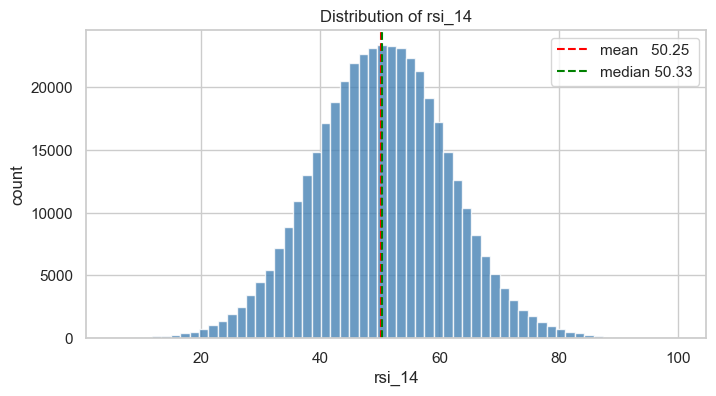

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(s, bins=60, color='steelblue', alpha=0.8)
ax.axvline(s.mean(),   color='red',   linestyle='--', label=f'mean   {s.mean():.2f}')
ax.axvline(s.median(), color='green', linestyle='--', label=f'median {s.median():.2f}')
ax.set_title(f'Distribution of {col}')
ax.set_xlabel(col); ax.set_ylabel('count'); ax.legend()
plt.show()

## Block 4 · Outliers
An **outlier** is a value far from the rest. Two standard ways to flag them:

1. **Z-score** — how many standard deviations from the mean. `|z| > 3` is a common cutoff.
2. **IQR rule** — anything below `Q1 - 1.5·IQR` or above `Q3 + 1.5·IQR`, where IQR = Q3 − Q1 (the box in a boxplot).

Outliers aren't automatically *bad* — in trading, the extreme bars are often the interesting ones. The skill is *noticing* them and *deciding* what they mean.

In [8]:
col = 'atr'   # ATR = volatility; expect a long right tail (occasional violent bars)
s = df[col].dropna()

# --- method 1: z-score ---
z = (s - s.mean()) / s.std()
z_out = s[z.abs() > 3]

# --- method 2: IQR ---
q1, q3 = s.quantile(0.25), s.quantile(0.75)
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_out = s[(s < lo) | (s > hi)]

print(f'{col}: {len(s):,} values')
print(f'  z-score (|z|>3) flags {len(z_out):,} outliers  ({100*len(z_out)/len(s):.2f}%)')
print(f'  IQR rule        flags {len(iqr_out):,} outliers  ({100*len(iqr_out)/len(s):.2f}%)')
print(f'  IQR fence: [{lo:.4f}, {hi:.4f}]')

atr: 424,729 values
  z-score (|z|>3) flags 6,447 outliers  (1.52%)
  IQR rule        flags 19,873 outliers  (4.68%)
  IQR fence: [-39.2937, 260.2832]


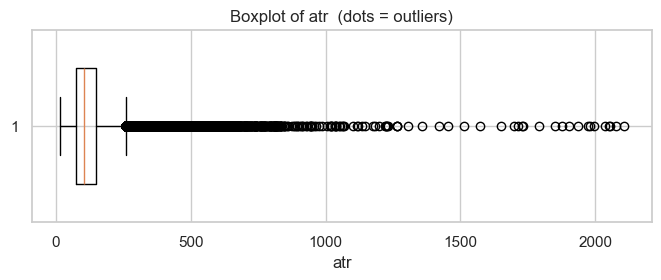

In [9]:
# A boxplot draws the IQR box + 'whiskers'; dots beyond the whiskers are the IQR outliers.
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.boxplot(s, vert=False, widths=0.6)
ax.set_title(f'Boxplot of {col}  (dots = outliers)')
ax.set_xlabel(col)
plt.show()

## Block 5 · Relationships between two columns — scatter
Before measuring correlation as a number, *look* at it. A scatter plot puts one column on X, another on Y, one dot per bar. We sample 5,000 rows so the plot isn't a solid blob.

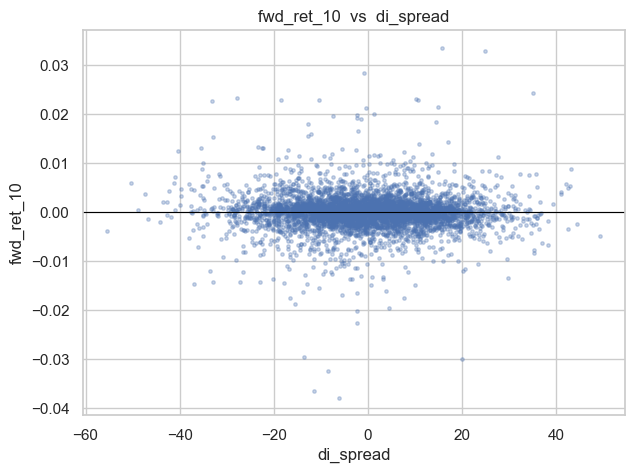

In [10]:
x_col, y_col = 'di_spread', 'fwd_ret_10'   # does DI spread relate to the next-10-bar return?

sample = df[[x_col, y_col]].dropna().sample(min(5000, len(df)), random_state=0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample[x_col], sample[y_col], s=6, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'{y_col}  vs  {x_col}')
ax.set_xlabel(x_col); ax.set_ylabel(y_col)
plt.show()

## Block 6 · Correlation
**Correlation** is a single number from −1 to +1 summarizing how two columns move together:
- **+1** = perfectly move up together, **−1** = perfectly opposite, **0** = no linear relationship.

⚠️ Two giant caveats, drilled into every quant:
1. **Correlation ≠ causation.** Moving together doesn't mean one causes the other.
2. Pearson correlation only sees *straight-line* relationships. A strong curved relationship can show near-zero correlation — which is exactly why we plotted first.

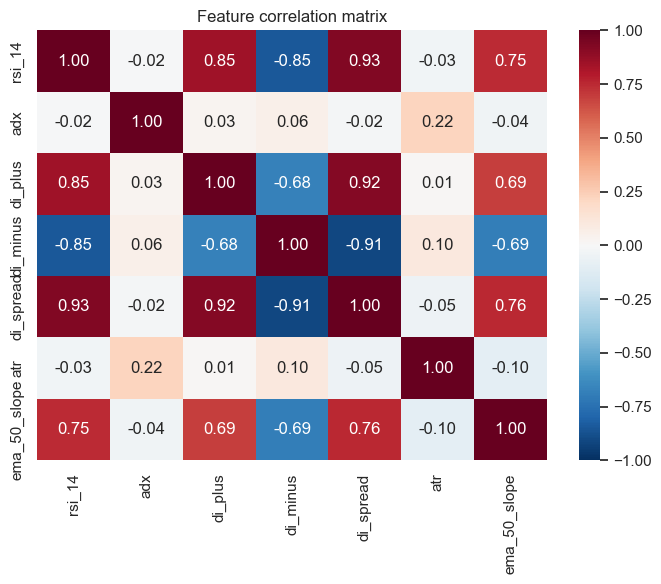

In [11]:
# Correlation matrix across a handful of features. Heatmap: red=positive, blue=negative.
cols = ['rsi_14', 'adx', 'di_plus', 'di_minus', 'di_spread', 'atr', 'ema_50_slope']
corr = df[cols].corr()   # pairwise correlation table

fig, ax = plt.subplots(figsize=(7, 6))
if HAVE_SNS:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
else:
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha='right')
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(im)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()

## Block 7 · The real question — which features predict forward returns?
This is the heart of the whole project. We correlate **every feature** against a forward-return label and rank them. The honest truth you'll discover: on raw data these correlations are **tiny** (think 0.01–0.05). That's normal — markets are mostly noise, and an edge is built from many small, *stable* signals, not one magic column.

(This mirrors what my Phase-5 discovery found: no lone feature is a silver bullet; volume-profile distance, hour-of-day, and the DI indicators carry the most weight.)

In [12]:
target = 'fwd_ret_10'   # try fwd_ret_5 / _20 / _60 too

# Pick only numeric feature columns (exclude the labels themselves and the timestamp).
label_cols = ['fwd_ret_5','fwd_ret_10','fwd_ret_20','fwd_ret_60','hit_tp_before_sl']
feature_cols = [c for c in df.select_dtypes('number').columns if c not in label_cols]

# Correlate each feature with the target, sort by absolute strength.
corrs = df[feature_cols].corrwith(df[target]).dropna()
ranked = corrs.reindex(corrs.abs().sort_values(ascending=False).index)

print(f'Top 12 features by |correlation| with {target}:\n')
print(ranked.head(12).to_string())

Top 12 features by |correlation| with fwd_ret_10:

ema_compression    0.014583
dist_vah          -0.013227
atr                0.011980
dist_poc          -0.011896
dist_val          -0.011872
close             -0.010841
dist_cloud        -0.010190
ema_75_dist       -0.008810
ema_100_dist      -0.008729
ema_50_dist       -0.008576
ema_200_dist      -0.008563
ema_75_slope      -0.007855


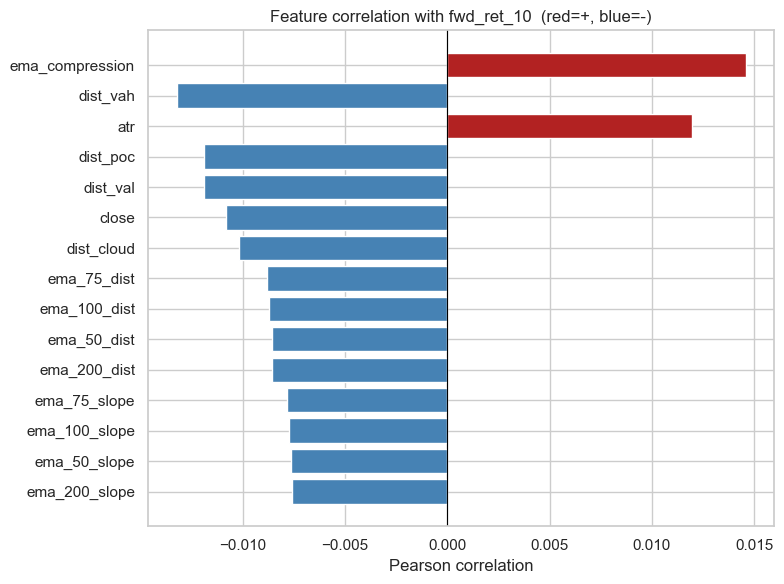

In [13]:
# Same thing as a horizontal bar chart — the top 15 by absolute correlation.
top = ranked.head(15)
colors = ['firebrick' if v > 0 else 'steelblue' for v in top.values]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Feature correlation with {target}  (red=+, blue=-)')
ax.set_xlabel('Pearson correlation')
plt.tight_layout(); plt.show()

## Block 8 · A quant-flavored slice — does the hour of day matter?
Discovery flagged **hour-of-day** as one of the strongest signals. Let's verify by hand: group bars by hour and look at the average forward return per hour. This is the `groupby` move — split rows into buckets, compute a stat per bucket.

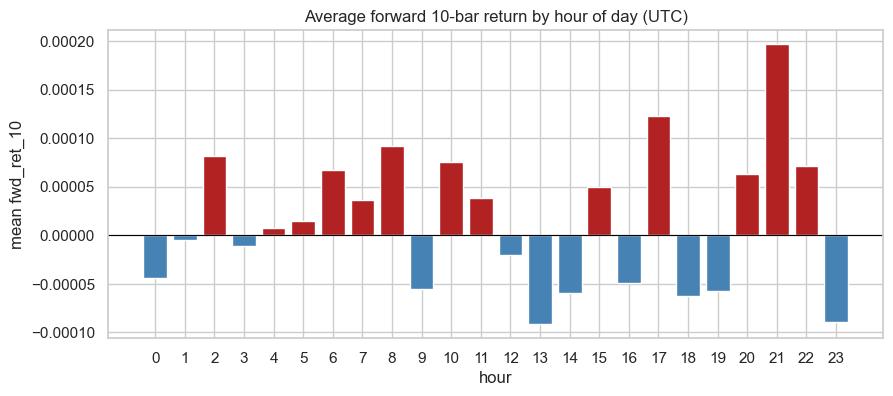

,mean,std,count
hour,,,
0,-0.000044,0.003942,17740
1,-0.000005,0.003769,17740
2,0.000082,0.003435,17750
3,-0.000010,0.002728,17746
4,0.000007,0.002729,17748
5,0.000015,0.002699,17710
6,0.000068,0.003312,17716
7,0.000036,0.002960,17706
8,0.000092,0.002923,17749


In [14]:
by_hour = df.groupby('hour')['fwd_ret_10'].agg(['mean', 'std', 'count'])

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['firebrick' if v > 0 else 'steelblue' for v in by_hour['mean']]
ax.bar(by_hour.index, by_hour['mean'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average forward 10-bar return by hour of day (UTC)')
ax.set_xlabel('hour'); ax.set_ylabel('mean fwd_ret_10')
ax.set_xticks(range(24))
plt.show()
by_hour

## 🎯 Your turn — baby-step exercises
Do these by copying a cell above and changing it. There are no wrong answers — the point is to build reflexes.

1. **Mean/std:** In Block 3, set `col = 'adx'`. Is ADX skewed? What does a right-skewed ADX mean about trend strength over time?
2. **Outliers:** In Block 4, try `col = 'fwd_ret_60'`. How many outliers? Those are the huge winning/losing moves — what % of all bars are they?
3. **Scatter:** In Block 5, try `x_col = 'rsi_14'`, `y_col = 'fwd_ret_5'`. Do you see a relationship, or a shapeless cloud? (Most will be clouds — that's the lesson.)
4. **Correlation target:** In Block 7, change `target` to `'fwd_ret_60'`. Do the top features change vs `fwd_ret_10`? Longer horizons sometimes show stronger structure.
5. **New data:** In Block 1, swap `_M3` for `_M1` in both paths to load the 1-minute timeframe. More rows, noisier. Re-run the notebook.
6. **Open-ended:** pick any feature whose name you don't understand (e.g. `cloud_thickness`, `dist_poc`) and ask me what it is and why it might matter.

When a result surprises you, that's the signal to ask: *"why did this come out this way?"* — bring it to me and we'll dig in together.